# Aeromagnetic data QC

This notebook demonstrates the use of functions to perform QC of aeromagnetic data.

Here we demonstrate their use on some aeromagnetic data from the Eastern Victoria survey.

Ensure you have run the `Prepare_AeromagData` notebook first so that the data are prepared for review.

___

First, import the required python packages, ...

In [1]:
from pathlib import Path
import pegasusQC as qc

... then set the path to the geowhizz files.

This is all very much step by step to illustrate the process, and you can certainly compress some of these steps in your own work.

In [2]:
dx = Path(r'./MagData/FD013_Mag.xyz')
dh = dx.with_suffix(".hdf5")

In [3]:
if not dh.exists():
    %run ./Prepare_AeromagData.ipynb

We will need channel names later so let's report them now.

In [4]:
qc.reportChannels(dh, verbose=True)

Whizz Version 1.0

17 channels:

  channel              units          description
--------------------------------------------------
  COMPMAG              nT             
  DCMAG                nT             
  DEM                  m              
  DIURNAL              nT             
  DOY                                 
  FLIGHT                              
  FTIME                               
  IGRFMAG              nT             
  LAT                  deg            
  LINE                                
  LONG                 deg            
  LVLDMAG              nT             
  MGA-X                m              
  MGA-Y                m              
  MGA-Z                m              
  MSL-Z                m              
  YEAR                                


___

A standard technical specification is the requirement that the basemag diurnal monitoring data, collected while each line is sampled, not deviate from a straight-line chord of a certain time span by more than a given number of nanoTesla.

The `checkDiurnal` function checks the data for such deviations in the given channel, deviations being less than `rangeLimit` over chords whose time span is `nSamples` long (as number of fids or samples).

  Checked 12 lines, 1 failed.


  L 2463.040: Diurnal for DIURNAL at sample number 3431 diverges from chord by 0.03, exceeding 0.0 - FAIL


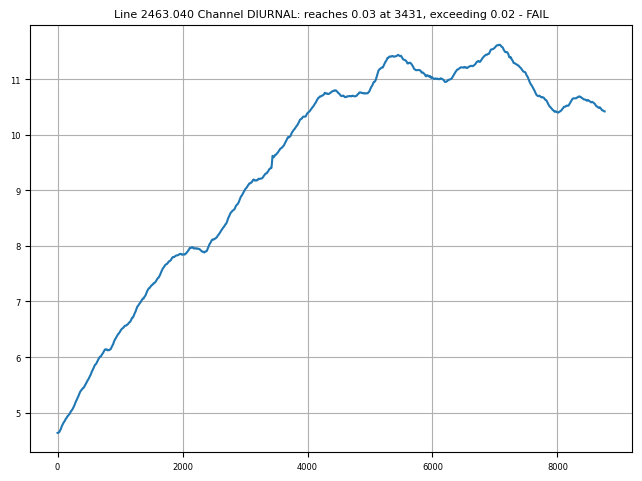

In [5]:
qc.checkDiurnal(dh, 'DIURNAL', lines=[],
                rangeLimit = 0.02, nSamples = 8, plot_flag=True)

___

The standard check for noise in aeromagnetic data is difference analysis. Very high frequency signal is assumed to be noise and this is measured by differencing the signal. Commonly the 4-th difference or 8-th difference is used.

The function `checkDiff` checks the total magnetic field n-th difference channel in a whizzFile against the specification that the peak to peak variation over a set number of samples must not exceed some peak value. If no n-th difference channel is supplied, then the raw magnetic data channel may be used, and its n-th difference will be calculated by the function.

The `GA Magnetic Deed` sets a specification:

    Magnetic noise on unfiltered magnetic data acquired during the survey must be less than 0.1 nT.
    The 8th difference will be used to assess the magnetic noise. If the signal of the 8th difference
    exceeds 0.1 nT over a distance of 1000 m the line will be re-flown at the contractor’s expense.
    
For a joint gravity-magnetic survey n-th difference noise is typically higher than for a solely magnetometer survey and technical specifications might be relaxed. 

The `plot_flag` and `verbose` Boolean parameters control whether the results are plotted, and whether a verbose report is given, as usual.

  Checked 12 line(s), 1 failure(s) over 1 failed line(s).

Line 2461.010: 2522 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
Line 2461.020: 657 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
Line 2461.030: 4955 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
Line 2463.000: 516 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
L 2463.020: 8-th difference > 0.001 for 338 > 300 fids; peak exceedance = 0.079 - FAIL
Line 2463.040: 8485 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
Line 2465.000: 2888 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
Line 2465.020: 6079 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
Line 2467.010: 2893 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
Line 2467.020: 5972 exceedances, less than 300 (0.0 m -> 300 fids) consecutively - PASS
Line 2469.000: 3128 exceedances, less than 300 (0.0 m -> 300 fid

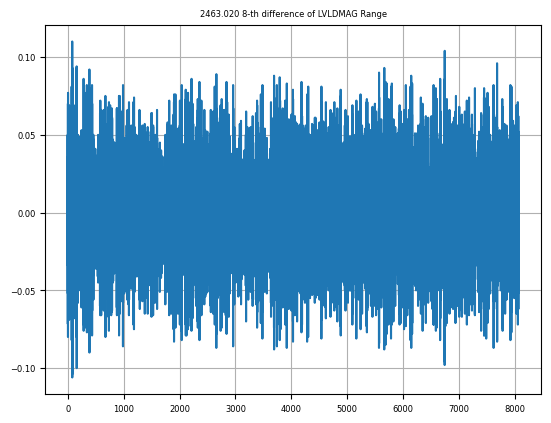

In [6]:
qc.checkDiff(dh, diff_chan='', raw_chan='LVLDMAG',
             lines=[],
             limit=0.001, nSamples=300, num_diff=8,
             plot_flag=True, verbose=True)

  Checked 12 line(s), 1 failure(s) over 1 failed line(s).
30.0 seconds evaluated as 299 fids.
Line 2461.010: 2522 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
Line 2461.020: 657 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
Line 2461.030: 4955 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
Line 2463.000: 516 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
L 2463.020: 8-th difference > 0.001 for 338 > 299 fids; peak exceedance = 0.079 - FAIL
Line 2463.040: 8485 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
Line 2465.000: 2888 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
Line 2465.020: 6079 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
Line 2467.010: 2893 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
Line 2467.020: 5972 exceedances, less than 299 (0.0 m -> 299 fids) consecutively - PASS
Line 2469.000: 3128 exceedanc

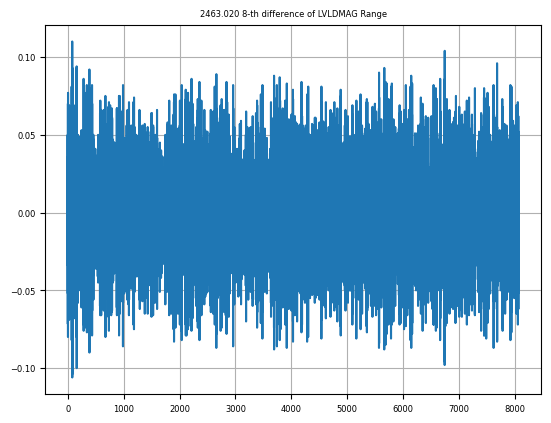

In [7]:
qc.checkDiff(dh, diff_chan='', raw_chan='LVLDMAG',
             lines=[],
             limit=0.001, maxDuration=30.0, num_diff=8,
             plot_flag=True, verbose=True)

  Checked 12 line(s), 1 failure(s) over 1 failed line(s).

Line 2461.010: 2522 exceedances, less than 302 (1800.0 m -> 302 fids) consecutively - PASS
Line 2461.020: 657 exceedances, less than 299 (1800.0 m -> 299 fids) consecutively - PASS
Line 2461.030: 4955 exceedances, less than 301 (1800.0 m -> 301 fids) consecutively - PASS
Line 2463.000: 516 exceedances, less than 300 (1800.0 m -> 300 fids) consecutively - PASS
L 2463.020: 8-th difference > 0.001 for 338 > 292 fids; peak exceedance = 0.079 - FAIL
Line 2463.040: 8485 exceedances, less than 297 (1800.0 m -> 297 fids) consecutively - PASS
Line 2465.000: 2888 exceedances, less than 307 (1800.0 m -> 307 fids) consecutively - PASS
Line 2465.020: 6079 exceedances, less than 302 (1800.0 m -> 302 fids) consecutively - PASS
Line 2467.010: 2893 exceedances, less than 295 (1800.0 m -> 295 fids) consecutively - PASS
Line 2467.020: 5972 exceedances, less than 296 (1800.0 m -> 296 fids) consecutively - PASS
Line 2469.000: 3128 exceedances, less

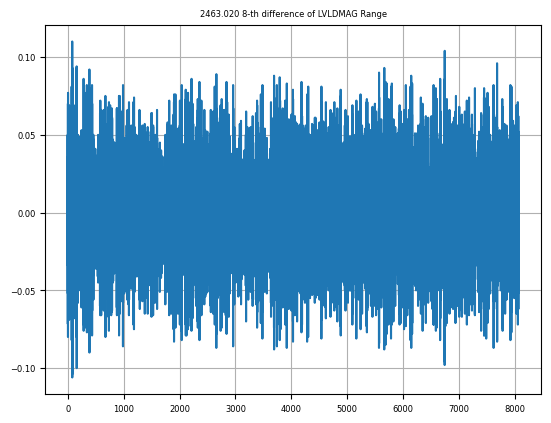

In [8]:
qc.checkDiff(dh, diff_chan='', raw_chan='LVLDMAG',
             lines=[],
             limit=0.001, maxDistance=1800.0, num_diff=8,
             plot_flag=True, verbose=True)

___

It is useful to check the power spectrum of the magnetic data because periodic noise sources can occur and these are often not seen in the standard 4th difference measure. This can be performed at each stage of processing, or just on the raw magnetic data and the final magnetic data. The power spectrum should not have any signs of harmonic signal.

In the example below, there are no spikes in the spectrum above $10^{-3}$ so all okay.

Of 12 lines in database, 10 will be processed.
The first 2634 samples from each line will be used.


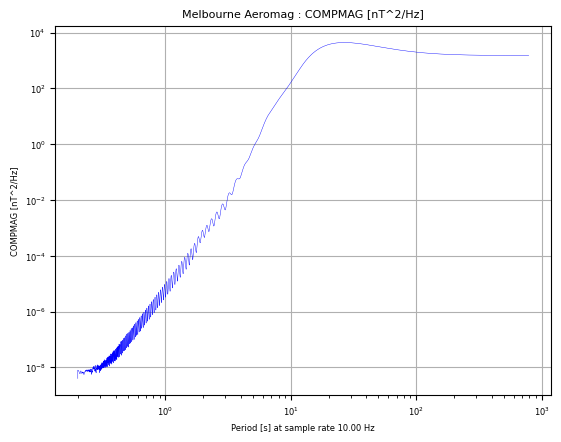

In [9]:
qc.psdChannel(dh, 'COMPMAG', flightLines=[], shortestPeriod=0.0, minlinelenkm=15.0, verbose=False)

___

There are other QC checks that should be performed but for which no QC function exists.

Magnetic compensation flights should be:

1. on a magnetically quiet location;
2. at high enough altitude to avoid short wavelength magnetic signal;
3. at a location where local magnetic field variations are less than 100 nT;
4. at a location where the magnetic field gradient is small;
5. with sufficient manoeuvre variation  to give more than 1000 nT signal in each fluxgate magnetometer;
6. over a flight path that forms a complete square;
7. with a fourth difference of the total field less than 0.1 nT over a 1000 m window;
8. delivering a figure-of-merit less than 2 nT.

A magnetometer lag calibration should be performed. Criteria are: ?##?

A magnetomer heading test should be performed. Criteria are: ?##?